# Configure

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from os.path import join
from pathlib import Path
import yaml
from yaml.loader import SafeLoader
import pandas as pd
import geopandas as gpd
import numpy as np
import rioxarray as rio
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick
import matplotlib.colors as colors
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import contextily as cx

In [4]:
# Name the fips, statefips, stateabbr, and nation that
# we are using for this analysis
fips_args = {
    'FIPS': ['42101'], 
    'STATEFIPS': ['42'],
    'STATEABBR': ['PA'],
    'NATION': ['US']
}
FIPS = fips_args['FIPS'][0]
NATION = fips_args['NATION'][0]

ABS_DIR = Path().absolute().parents[0]

CONFIG_FILEP = join(ABS_DIR, 'config', 'config.yaml')
# Open the config file and load
with open(CONFIG_FILEP) as f:
    CONFIG = yaml.load(f, Loader=SafeLoader)

# Wildcards for urls
URL_WILDCARDS = CONFIG['url_wildcards']

# Get the file extensions for api endpoints
API_EXT = CONFIG['api_ext']

# Get the CRS constants
NSI_CRS = CONFIG['nsi_crs']

# Dictionary of ref_names
REF_NAMES_DICT = CONFIG['ref_names']

# Dictionary of ref_id_names
REF_ID_NAMES_DICT = CONFIG['ref_id_names']

# Coefficient of variation
# for structure values
COEF_VARIATION = CONFIG['coef_var']

# First floor elevation dictionary
FFE_DICT = CONFIG['ffe_dict']

# Number of states of the world
N_SOW = CONFIG['sows']

# Data for flood depth grids
# Get hazard model variables
HAZ_FILEN = CONFIG['haz_filename']
# Get CRS for depth grids
HAZ_CRS = CONFIG['haz_crs']
# Ensemble members
HAZ_NENS = CONFIG['haz_nens']
# Number of columns for each depth grid
HAZ_NCOLS = CONFIG['haz_ncols']
# Num rows for each depth grid
HAZ_NROWS = CONFIG['haz_nrows']
# Lower left x coordinate
HAZ_XLL = CONFIG['haz_xll']
# Lower left y coordinate
HAZ_YLL = CONFIG['haz_yll']
# Cell resolution
HAZ_RES = CONFIG['haz_res']
# NODATA values
HAZ_NODATA = CONFIG['haz_nodata']

# Get the files we need downloaded
DOWNLOAD = pd.json_normalize(CONFIG['download'], sep='_').T

# We can also specify the filepath to the
# raw data directory
FR = join(ABS_DIR, "data", "raw")

# And external - where our hazard data should be
FE = join(FR, "external")

# Set up interim and results directories as well
# We already use "FR" for raw, we use "FO" 
# because you can also think of results
# as output
FI = join(ABS_DIR, "data", "interim")
FO = join(ABS_DIR, "data", "results")

# For figures
FIG_DIR = join(ABS_DIR, "fig")

# "Raw" data directories for exposure, vulnerability (vuln) and
# administrative reference files
EXP_DIR_R = join(FR, "exp")
VULN_DIR_R = join(FR, "vuln")
REF_DIR_R = join(FR, "ref")
# Haz is for depth grids
HAZ_DIR_R = join(FE, "haz")
# Pol is for NFHL
POL_DIR_R = join(FR, "pol")

# Unzip directory 
UNZIP_DIR = join(FR, "unzipped")

# We want to process unzipped data and move it
# to the interim directory where we keep
# processed data
# Get the filepaths for unzipped data
# We unzipped the depth grids (haz) and 
# ddfs (vuln) into the "external"/ subdirectory
HAZ_DIR_UZ = join(UNZIP_DIR, "external", "haz")
POL_DIR_UZ = join(UNZIP_DIR, "pol")
REF_DIR_UZ = join(UNZIP_DIR, "ref")
VULN_DIR_UZ = join(UNZIP_DIR, "external", "vuln")

# Our study domain
CLIP_SHP_FILEP = join(HAZ_DIR_UZ, 'RIFT_domain', 'domain_1.shp')

# "Interim" data directories
EXP_DIR_I = join(FI, "exp")
VULN_DIR_I = join(FI, "vuln")
REF_DIR_I = join(FI, "ref")
# Haz is for depth grids
HAZ_DIR_I = join(FI, "haz")
# Pol is for NFHL
POL_DIR_I = join(FI, "pol")

# Load data

In [5]:
# Helpful to store the dataframes as a dictionary where the 
# experiment name is the key
# The naming conventions are different for considering uncertainty
# and this code accounts for that
output_dir = join(FO, 'ensembles')
dg_id = "009"
exps = ['phil', 'nsi_ddfs', 'nsi_unsafe',
        'nsi_phil', 'phil_unsafe', 'nsi_allphil']

all_results = {}
for exp_name in exps:
    main_exp_name = f"main_exp_{dg_id}_{exp_name}_main.pqt"
    ens_result = pd.read_parquet(join(output_dir, main_exp_name))
    all_results[exp_name] = ens_result

nounc_name = f"no_unc_{dg_id}_main.pqt"
all_results["no_unc"] = pd.read_parquet(join(output_dir, nounc_name))

In [6]:
# Spatial data
clip_geo = gpd.read_file(CLIP_SHP_FILEP)
tract_ref = gpd.read_file(join(REF_DIR_I, FIPS, 'tract.gpkg'))[['GEOID', 'geometry']]

# Inventories
# Spatial
nsi_clip_out = gpd.read_file(join(EXP_DIR_I, FIPS, 'nsi_res.gpkg'))
phil_inv_out = gpd.read_file(join(EXP_DIR_I, FIPS, 'phil_res.gpkg'))
# Ensembles
phil_inv_ens = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_inv_ens.pqt'))
nsi_inv_ens = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_inv_ens.pqt'))

# Data to link inventories to tracts
phil_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_ref.pqt'))
nsi_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_ref.pqt'))

# Depths across inundation model ensembles
nsi_depths_df = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_depths_updated.pqt'))#.set_index('fd_id')
phil_depths_df = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_depths.pqt')).set_index('bfid')

# Postprocessing

In [7]:
# Can only choose depth grids that we generated ensembles for
dg_id = '009'
dam_col = 'naccs_loss_' + dg_id

In [8]:
# Reference of nsi records linked to philly footprints
lnk_nsi_loc = gpd.sjoin(nsi_clip_out,
                        phil_inv_out,
                        predicate='within',
                        how='inner')

# Use the spatial links to add bfid to the nsi data
fd_bfid_lnk = dict(zip(lnk_nsi_loc['fd_id'], lnk_nsi_loc['bfid']))
nsi_match = nsi_inv_ens.reset_index()
nsi_match['bfid'] = nsi_match['fd_id'].map(fd_bfid_lnk)
# We will link up all the records across inventories
# including those w/o a match in the other in order to define
# different match categories

nsi_match.loc[nsi_match['bfid'].isnull(), 'bfid'] = nsi_match.loc[nsi_match['bfid'].isnull()]['fd_id']

match_df = nsi_match.merge(phil_inv_ens.reset_index(),
                           on='bfid',
                           suffixes=['_nsi', '_phil'],
                           how='outer')

# matches = match_df.groupby(['bfid', 'num_story_phil', 'found_type_phil',
#                             'occtype_phil', 'occtype_nsi',
#                             'num_story_nsi', 'found_type_nsi']).size().rename('n').reset_index()

matches = match_df.groupby(['bfid', 'num_story_phil', 'found_type_phil',
                            'num_story_nsi', 'found_type_nsi']).size().rename('n').reset_index()

matches['story_match'] = 0
matches.loc[matches['num_story_phil'] == matches['num_story_nsi'],
            'story_match'] = 1

matches['found_type_match'] = 0
matches.loc[matches['found_type_phil'] == matches['found_type_nsi'],
            'found_type_match'] = 1

# matches['occ_match'] = 0
# matches.loc[matches['occtype_phil'] == matches['occtype_nsi'],
#             'occ_match'] = 1

# matches.loc[(matches['story_match'] == 0) &
#             (matches['found_type_match'] == 0) &
#             (matches['occ_match'] == 0),
#             'Matches'] = 'Location Only'

# matches.loc[((matches['story_match'] == 1) &
#              (matches['found_type_match'] == 1) &
#              (matches['occ_match'] == 1)),
#             'Matches'] = 'All'

# matches.loc[((matches['story_match'] == 1) &
#              (matches['found_type_match'] == 1) &
#              (matches['occ_match'] == 0)),
#             'Structure Matches'] = 'Basement & Stories'

# matches.loc[((matches['story_match'] == 1) &
#              (matches['found_type_match'] == 0) &
#              (matches['occ_match'] == 0)),
#             'Structure Matches'] = 'Stories'

# matches.loc[((matches['story_match'] == 0) &
#              (matches['found_type_match'] == 1) &
#              (matches['occ_match'] == 0)),
#             'Structure Matches'] = 'Basement'

# matches.loc[((matches['story_match'] == 0) &
#              (matches['found_type_match'] == 0) &
#              (matches['occ_match'] == 1)),
#             'Structure Matches'] = 'Occupancy'

# matches.loc[((matches['story_match'] == 1) &
#              (matches['found_type_match'] == 0) &
#              (matches['occ_match'] == 1)),
#             'Structure Matches'] = 'Stories & Occupancy'

# matches.loc[((matches['story_match'] == 0) &
#              (matches['found_type_match'] == 1) &
#              (matches['occ_match'] == 1)),
#             'Structure Matches'] = 'Basement & Occupancy'

matches.loc[(matches['story_match'] == 0) &
            (matches['found_type_match'] == 0),
            'Matches'] = 'Location Only'

matches.loc[((matches['story_match'] == 1) &
             (matches['found_type_match'] == 1)),
            'Matches'] = 'All'

matches.loc[((matches['story_match'] == 1) &
             (matches['found_type_match'] == 0)),
            'Matches'] = 'Stories'

matches.loc[((matches['story_match'] == 0) &
             (matches['found_type_match'] == 1)),
            'Matches'] = 'Basement'

# match_agg_l = ['Stories', 'Basement', 'Occupancy', 'Stories & Occupancy',
#                'Basement & Stories', 'Basement & Occupancy']
# matches.loc[matches['Structure Matches'].isin(match_agg_l),
#             'Matches'] = 'Location & Subset'

# If more than one NSI linked to same bfid, update match type
many_nsi = match_df.groupby(['bfid']).size().rename('n').reset_index()
many_nsi_ids = many_nsi[many_nsi['n'] > 1]['bfid']
matches.loc[matches['bfid'].isin(many_nsi_ids),
            'Matches'] = 'Many NSI In One Philly'

match_dict = dict(zip(matches['bfid'].astype(int), matches['Matches']))
# specific_match_dict = dict(zip(matches['bfid'].astype(int), matches['Structure Matches']))

phil_only = match_df[(~match_df['bfid'].isin(matches['bfid'])) & (match_df['fd_id'].isnull())]
phil_only['Matches'] = 'Unmatched Philly'
# Sometimes there will be a NSI property matched to a Philly property, but it 
# doesn't match our inventory. We limited nsi_inv_ens and phil_inv_ens to 
# <= 3 stories, for instance. If the NSI has the wrong entry for this, it will
# be the same as "NSI Not In Philly" for our purposes because that refers to
# the inventory match
nsi_only = match_df[(~match_df['bfid'].isin(matches['bfid'])) & (match_df['fd_id'].notnull())]
nsi_only['Matches'] = 'NSI Not In Philly'

phil_only_dict = dict(zip(phil_only['bfid'].astype(int), phil_only['Matches']))
nsi_only_dict = dict(zip(nsi_only['bfid'].astype(int), nsi_only['Matches']))

match_dict |= phil_only_dict
match_dict |= nsi_only_dict

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_9120/2661761342.py:112: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phil_only['Matches'] = 'Unmatched Philly'
/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_9120/2661761342.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nsi_only['Matches'] = 'NSI Not In Philly'


In [9]:
# Combine the mean damage estimates from the ensemble
# of NSI fixed, DDF uncertain with the NSI inventory
nsi_ddf_unc = all_results['nsi_ddfs']
# Add a rel_loss column
nsi_ddf_unc['rel_loss'] = nsi_ddf_unc[dam_col]/nsi_ddf_unc['val_s']
# All nan correspond to no estimated damages
nsi_ddf_mean = nsi_ddf_unc.groupby('fd_id')[[dam_col, 'rel_loss']].mean().fillna(0)
main_nsi = nsi_inv_ens.join(nsi_ddf_mean).reset_index()

main_phil = all_results['phil']
# main_phil = main_phil.groupby('bfid')[dam_col].mean().reset_index()
main_phil = main_phil.merge(phil_inv_ens.reset_index(), on='bfid')

main_nsi['bfid'] = main_nsi['fd_id'].map(fd_bfid_lnk)

# Calculate Phil relative damage and include that in the mean step after merge
main_phil['rel_loss'] = main_phil[dam_col]/main_phil['val_s']

# Merge depths in
main_nsi[dg_id] = main_nsi['fd_id'].map(nsi_depths_df[dg_id])*3.28084
main_phil[dg_id] = main_phil['bfid'].map(phil_depths_df[dg_id])*3.28084

merge_cols = ['bfid', dam_col, dg_id, 'rel_loss', 'val_s',
              'num_story', 'found_type', 'occtype']

phil_mean = main_phil.groupby('bfid').agg({dam_col: 'mean',
                                           dg_id: 'first',
                                           'rel_loss': 'mean',
                                           'val_s': 'mean',
                                           'occtype': 'first',
                                           'num_story': 'first',
                                           'found_type': 'first'}).reset_index()

test = main_nsi.merge(phil_mean[merge_cols],
                      suffixes=['_nsi', '_phil'],
                      on='bfid',
                      how='outer')

# If bfid is null or Philly damage is 0, use fd_id in its place so we have a unique id
# We also look at Philly damage being 0 because if that's the case there's no depth
# for the property at that bfid and we want to use the fd_id instead for merging
# depths in later
fd_id_mask = test['bfid'].isnull() # | test[dam_col+'_phil'].isnull()
test.loc[fd_id_mask, 'bfid'] = test.loc[fd_id_mask, 'fd_id']

# NSI buildings can be stacked on top of each other so we'll aggregate these
# and treat them like one structure
test_gb = test.groupby(['bfid']).agg({dam_col + '_nsi': 'sum',
                                      dam_col + '_phil': 'first',
                                      dg_id + '_nsi': 'first',
                                      dg_id + '_phil': 'first',
                                      'val_struct': 'sum',
                                      'val_s': 'first',
                                      'rel_loss_nsi': 'first',
                                      'rel_loss_phil': 'first'}).reset_index().fillna(0)

test_gb['bfid'] = test_gb['bfid'].astype(int)

test_gb['nsi_rank'] = test_gb[dam_col+'_nsi'].rank(ascending=False, method='min')
test_gb['phil_rank'] = test_gb[dam_col+'_phil'].rank(ascending=False, method='min')

# Dam and rank diff
test_gb['diff'] = test_gb[dam_col+'_nsi'] - test_gb[dam_col+'_phil']
test_gb['diff_rel'] = test_gb['rel_loss_nsi'] - test_gb['rel_loss_phil']
test_gb['rank_diff'] = test_gb['nsi_rank'] - test_gb['phil_rank']
test_gb['diff_m'] = test_gb['diff']/1e6
# value diff
test_gb['diff_val'] = test_gb['val_struct'] - test_gb['val_s']


# For visualization purposes, create an artificial high fillna value
test_gb.loc[test_gb['nsi_rank'].isnull(), 'nsi_rank'] = len(test_gb) 
test_gb.loc[test_gb['phil_rank'].isnull(), 'phil_rank'] = len(test_gb)


test_gb['Matches'] = test_gb['bfid'].map(match_dict)# .fillna('Philly Only (No Match)')
# test_gb['Structure Matches'] = test_gb['bfid'].map(specific_match_dict)

# Get depth back in 
test_gb['depth_ft'] = (test_gb['bfid'].map(phil_depths_df[dg_id])*3.28084)
test_gb.loc[test_gb['depth_ft'].isnull(),
            'depth_ft'] = test_gb['bfid'].map(nsi_depths_df[dg_id])*3.28084

# Id for "true" damage
test_gb['phil_dam'] = 0
test_gb.loc[test_gb['bfid'].isin(phil_mean['bfid']), 'phil_dam'] = 1

# Assign depths based on damage source
test_gb.loc[test_gb['phil_dam'] == 1, 'depth_ft'] = test_gb.loc[test_gb['phil_dam'] == 1, dg_id+'_phil']
test_gb.loc[test_gb['phil_dam'] == 0, 'depth_ft'] = test_gb.loc[test_gb['phil_dam'] == 0, dg_id+'_nsi']

# Update match column where no Philly damages
# test_gb.loc[test_gb['phil_dam'] == 0, 'Matches'] = 'NSI Only (No Match)'

# We only want to keep columns where there is damage in either record 
test_gb = test_gb.loc[(test_gb['phil_dam'] == 1) | (test_gb[dam_col+'_nsi'] > 0)]

# Get tract_id back in
test_gb['tract_id'] = test_gb['bfid'].map(phil_refs.set_index('bfid')['tract_id'])
test_gb.loc[test_gb['tract_id'].isnull(),
            'tract_id'] = test_gb['bfid'].map(nsi_refs.set_index('fd_id')['tract_id'])

# For cumulative discrepancies we are doing it using the mean from the ensemble
# as our best guess damage for the property

test_gb['depth_plot'] = test_gb['depth_ft'].round(1)
test_gb['cm_diff'] = test_gb.sort_values('depth_plot').groupby('Matches')['diff'].transform('cumsum')/1e6

test_gb['cm_diff_agg'] = test_gb.sort_values('depth_plot')['diff'].transform('cumsum')/1e6

# For plotting, these are helpful
test_gb['depth_bins'] = pd.cut(test_gb['depth_ft'],
                              bins=[0, 1, 2, 4, test_gb['depth_ft'].max()])
test_gb['diff_thou'] = test_gb['diff']/1e3

In [10]:
# We also want to know individual DDF matches
# Get foundation difference
match_df.loc[(match_df['found_type_nsi'] == 'B')  &
             (match_df['num_story_nsi'] == 1), 'NSI DDF'] = '1SWB'

match_df.loc[(match_df['found_type_nsi'] == 'S')  &
             (match_df['num_story_nsi'] == 1), 'NSI DDF'] = '1SNB'

match_df.loc[(match_df['found_type_nsi'] == 'B')  &
             (match_df['num_story_nsi'] == 2), 'NSI DDF'] = '2SWB'

match_df.loc[(match_df['found_type_nsi'] == 'S')  &
             (match_df['num_story_nsi'] == 2), 'NSI DDF'] = '2SNB'

match_df.loc[(match_df['found_type_phil'] == 'B')  &
             (match_df['num_story_phil'] == 1), 'Philly DDF'] = '1SWB'

match_df.loc[(match_df['found_type_phil'] == 'S')  &
             (match_df['num_story_phil'] == 1), 'Philly DDF'] = '1SNB'

match_df.loc[(match_df['found_type_phil'] == 'B')  &
             (match_df['num_story_phil'] == 2), 'Philly DDF'] = '2SWB'

match_df.loc[(match_df['found_type_phil'] == 'S')  &
             (match_df['num_story_phil'] == 2), 'Philly DDF'] = '2SNB'

# Map by bfid to test_gb
nsi_ddfs = dict(zip(match_df['bfid'], match_df['NSI DDF']))
phil_ddfs = dict(zip(match_df['bfid'], match_df['Philly DDF']))

test_gb['nsi_ddfs'] = test_gb['bfid'].map(nsi_ddfs)
test_gb['phil_ddfs'] = test_gb['bfid'].map(phil_ddfs)

test_gb['ddf_match'] = 'NSI: ' + test_gb['nsi_ddfs'] + '\nPhilly: ' + test_gb['phil_ddfs']
test_gb.loc[test_gb['nsi_ddfs'] == test_gb['phil_ddfs'],
             'ddf_match'] = 'Both ' + test_gb['phil_ddfs']

In [11]:
# Link nsi_ddf_unc observations to bfid
# Connect each corresponding observation by id & sow_ind
# We're only going to focus on the observations
# that have location links
# Calculate w/in sow value, rel_loss, and damage discrepancies
# Link the match_df DDF comparisons to this data
# Plot DDF match type on x-axis
# Show rel_loss, val, and dam discrep in different panels
# show # of observations on bottom panel
# Create a hue for the depth bins

nsi_ddf_unc['bfid'] = nsi_ddf_unc['fd_id'].map(fd_bfid_lnk)

# Subset to Matches we care about
nsi_ddf_unc['Matches'] = nsi_ddf_unc['bfid'].map(match_dict)
nsi_ddf_unc_sub = nsi_ddf_unc[nsi_ddf_unc['Matches'].isin(['Location Only',
                                                           'Stories',
                                                           'Basement',
                                                           'All'])]

# Inner merge
comb_ens = nsi_ddf_unc_sub.merge(main_phil,
                             on=['bfid', 'sow_ind'],
                             how='inner',
                             suffixes=['_nsi', '_phil'])

# Discrep columns
comb_ens['val_diff'] = comb_ens['val_s_nsi'] - comb_ens['val_s_phil']
comb_ens['rel_diff'] = comb_ens['rel_loss_nsi'] - comb_ens['rel_loss_phil']
comb_ens['loss_diff'] = comb_ens[f'{dam_col}_nsi'] - comb_ens[f'{dam_col}_phil']

# DDF match columns
comb_ens['nsi_ddfs'] = comb_ens['bfid'].map(nsi_ddfs)
comb_ens['phil_ddfs'] = comb_ens['bfid'].map(phil_ddfs)

# Combine DDF columns to create a match column
# When they are identical, change name to "Both XSXB"
comb_ens['ddf_match'] = 'NSI: ' + comb_ens['nsi_ddfs'] + '\nPhilly: ' + comb_ens['phil_ddfs']
comb_ens.loc[comb_ens['nsi_ddfs'] == comb_ens['phil_ddfs'],
             'ddf_match'] = 'Both ' + comb_ens['phil_ddfs']

# We will only plot the subset of Philly 2 stories
plot_sub = comb_ens[comb_ens['stories_phil'] == '2S']

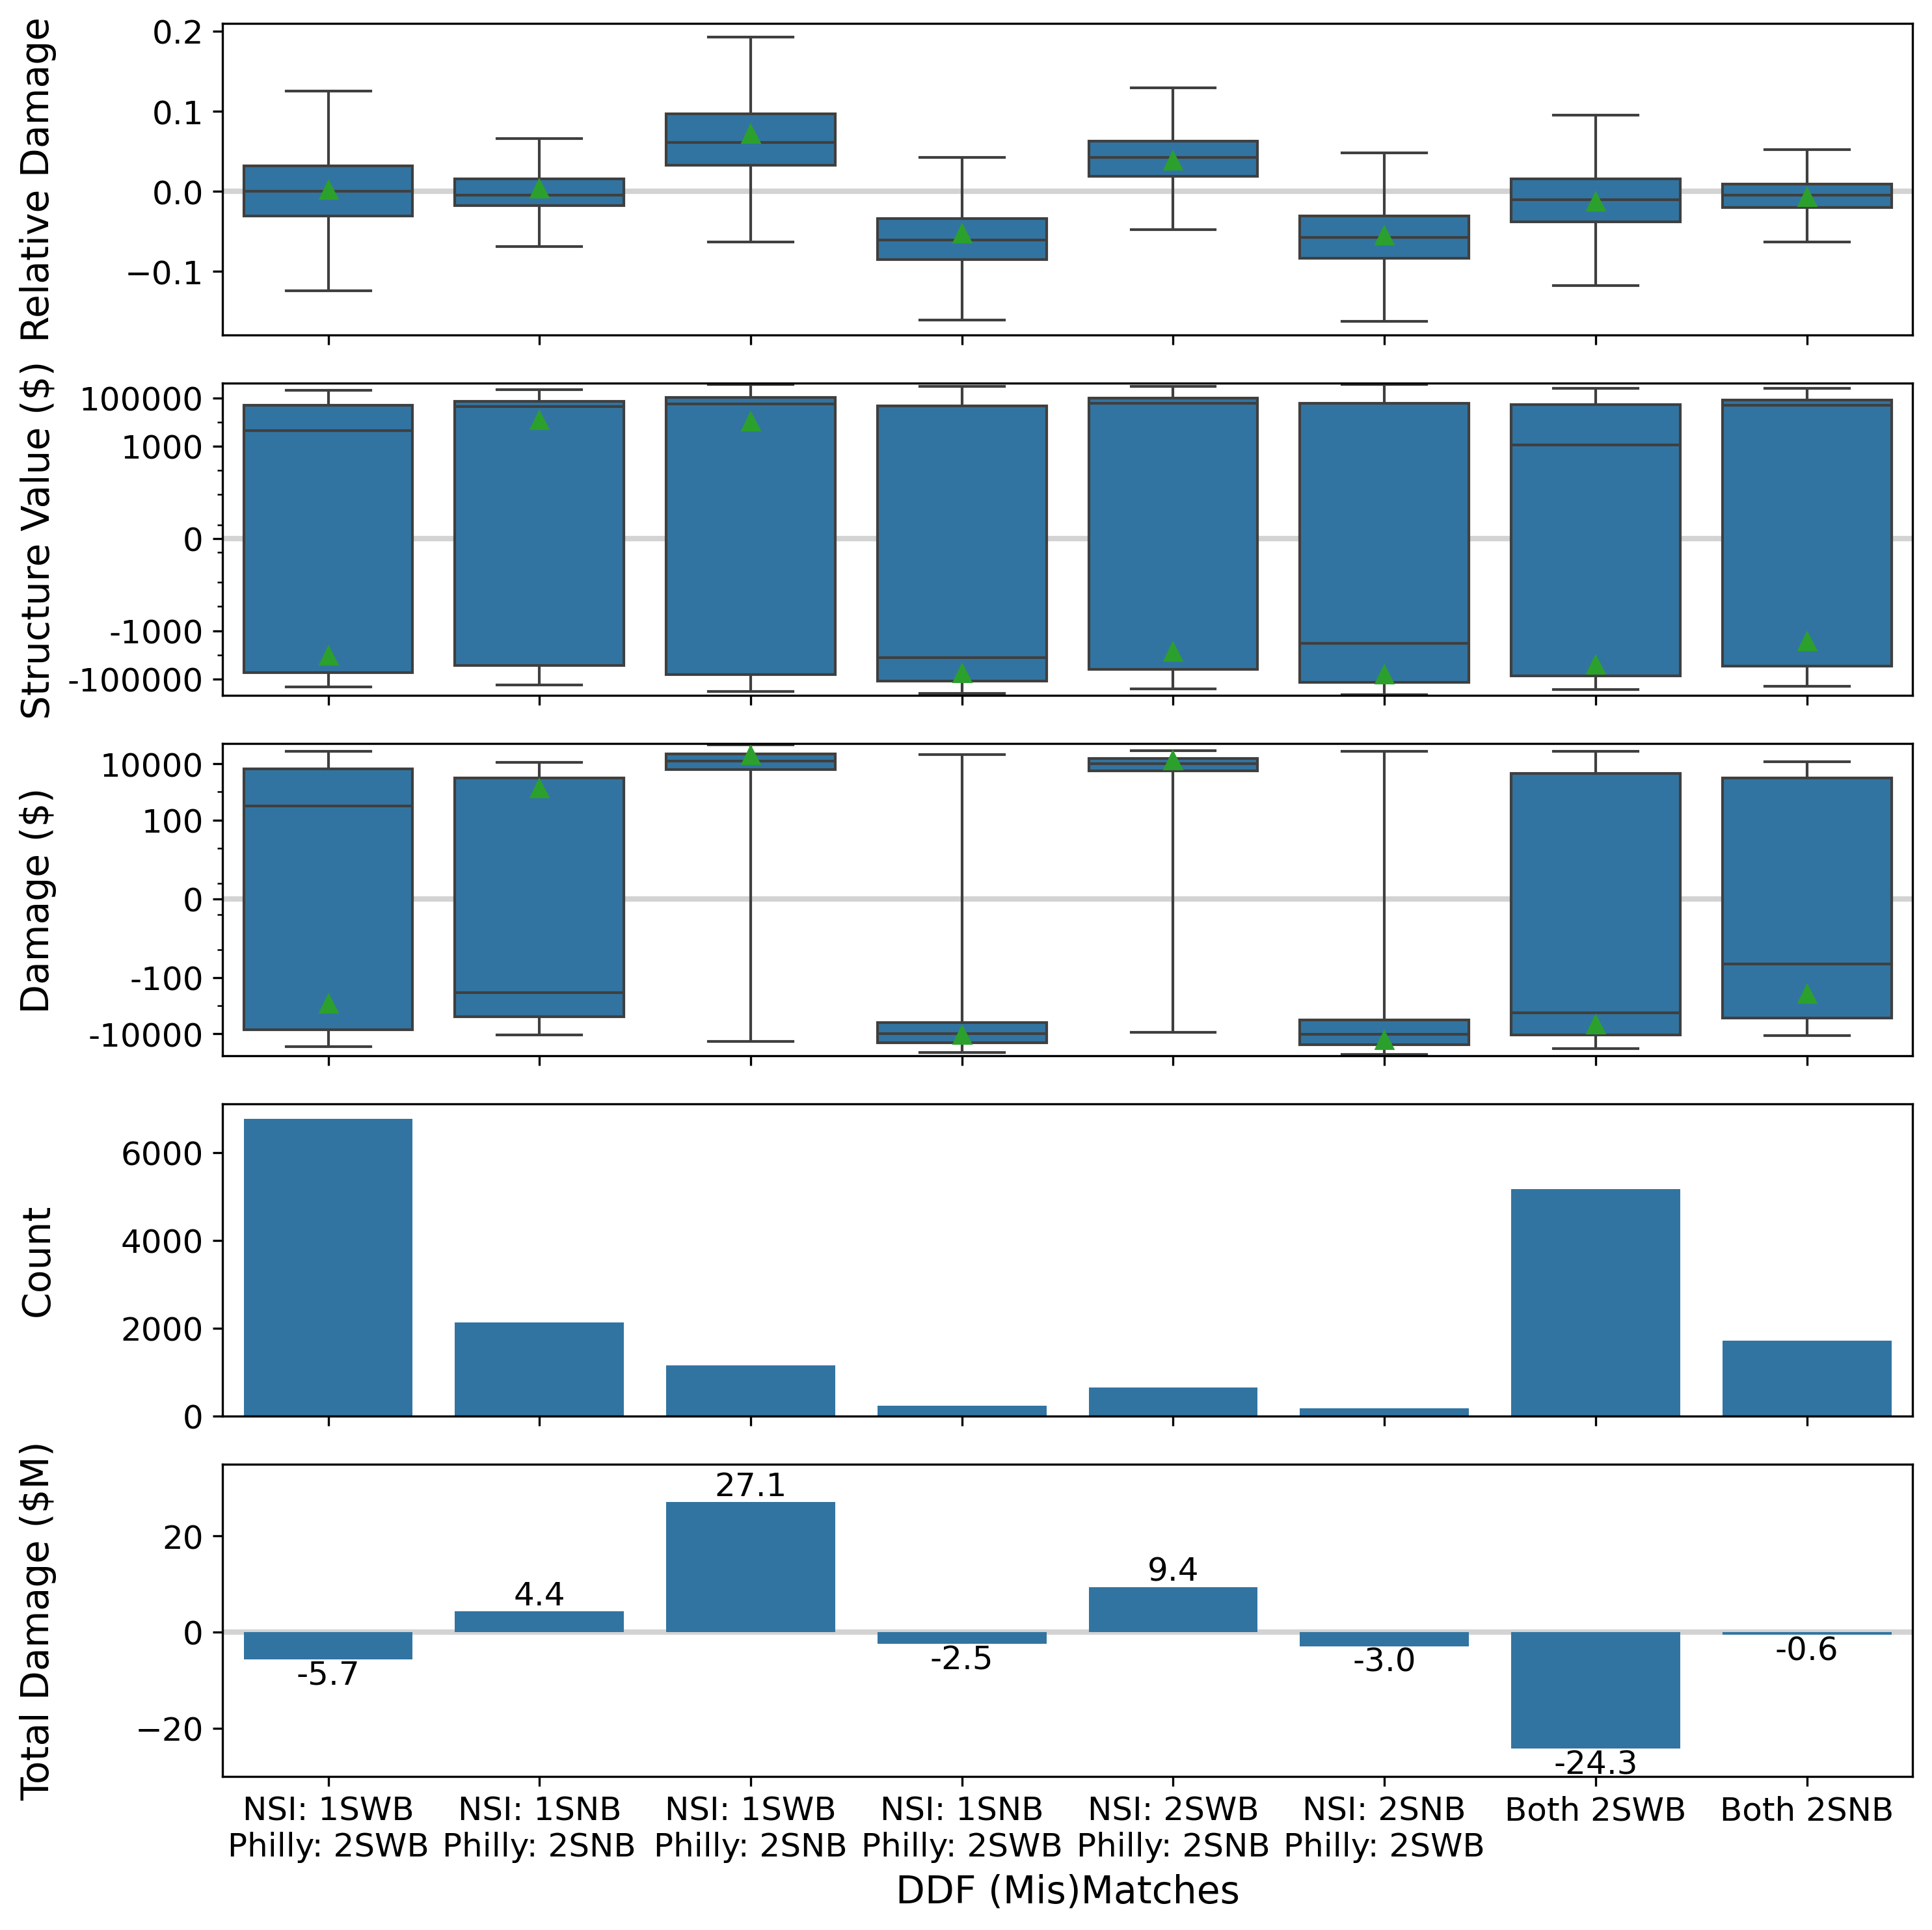

In [12]:
fig, ax = plt.subplots(figsize=(10, 10), nrows=5, sharex=True, dpi=300)

order = ['NSI: 1SWB\nPhilly: 2SWB', 
         'NSI: 1SNB\nPhilly: 2SNB',
         'NSI: 1SWB\nPhilly: 2SNB',
         'NSI: 1SNB\nPhilly: 2SWB',
         'NSI: 2SWB\nPhilly: 2SNB',
         'NSI: 2SNB\nPhilly: 2SWB',
         'Both 2SWB',
         'Both 2SNB']

ax[0].axhline(0, lw=2, color='lightgray', zorder=0)

sns.boxplot(data=plot_sub,
            x='ddf_match',
            order=order, 
            y='rel_diff',
            showmeans=True,
            showfliers=False,
            ax=ax[0])

ax[1].axhline(0, lw=2, color='lightgray', zorder=0)

sns.boxplot(data=plot_sub,
            x='ddf_match',
            order=order, 
            y='val_diff',
            showmeans=True,
            showfliers=False,
            ax=ax[1])

ax[2].axhline(0, lw=2, color='lightgray', zorder=0)

sns.boxplot(data=plot_sub,
            x='ddf_match',
            order=order, 
            y='loss_diff',
            showmeans=True,
            showfliers=False,
            ax=ax[2])

sns.countplot(data=test_gb,
            x='ddf_match',
            order=order, 
            ax=ax[3])

ax[4].axhline(0, lw=2, color='lightgray', zorder=0)
test_gb['diff_mil'] = test_gb['diff']/1e6
sns.barplot(data=test_gb,
            x='ddf_match',
            y='diff_mil',
            estimator='sum',
            errorbar=None,
            order=order, 
            ax=ax[4])
ax[4].bar_label(ax[4].containers[0], fmt='%.1f', fontsize=12)
ax[4].set_ylim(-30, 35)

ax[1].set_yscale('symlog')
ax[2].set_yscale('symlog')

# Define formatter
def format_func(value, tick_number):
    return f'{int(value)}'

# Apply formatter
formatter = FuncFormatter(format_func)
ax[1].yaxis.set_major_formatter(formatter)
ax[2].yaxis.set_major_formatter(formatter)

ax[1].set_yticks([-100000, -1000, 0, 1000, 100000])
ax[2].set_yticks([-10000, -100, 0, 100, 10000])

ax[0].set_ylabel('Relative Damage', size=14)
ax[1].set_ylabel('Structure Value ($)', size=14)
ax[2].set_ylabel('Damage ($)', size=14)
ax[3].set_ylabel('Count', size=14)
ax[4].set_ylabel('Total Damage ($M)', size=14)
ax[4].set_xlabel('DDF (Mis)Matches', size=14)

fig.align_ylabels(ax)

for k, axis in enumerate(ax):
    axis.tick_params(labelsize=12)

fig.tight_layout()

In [21]:
test_gb.groupby('ddf_match').agg({'diff_rel': ['mean', 'median']})

diff_rel          
                             mean    median
ddf_match                                  
Both 1SNB               -0.002418  0.003576
Both 1SWB               -0.014832 -0.014236
Both 2SNB               -0.007007 -0.000330
Both 2SWB               -0.012598 -0.012574
NSI: 1SNB\nPhilly: 1SWB -0.071146 -0.067683
NSI: 1SNB\nPhilly: 2SNB  0.004551  0.002404
NSI: 1SNB\nPhilly: 2SWB -0.052249 -0.057033
NSI: 1SWB\nPhilly: 1SNB  0.056045  0.057459
NSI: 1SWB\nPhilly: 2SNB  0.071737  0.055958
NSI: 1SWB\nPhilly: 2SWB  0.001623 -0.002320
NSI: 2SNB\nPhilly: 1SNB -0.000046  0.003162
NSI: 2SNB\nPhilly: 2SWB -0.055399 -0.056808
NSI: 2SWB\nPhilly: 1SNB  0.050161  0.050161
NSI: 2SWB\nPhilly: 1SWB -0.032889 -0.024869
NSI: 2SWB\nPhilly: 2SNB  0.038010  0.045658

In [18]:
test_gb.groupby('ddf_match')['diff_mil'].sum()

ddf_match
Both 1SNB                   0.036602
Both 1SWB                  -0.058978
Both 2SNB                  -0.593891
Both 2SWB                 -24.285645
NSI: 1SNB\nPhilly: 1SWB    -0.025294
NSI: 1SNB\nPhilly: 2SNB     4.382947
NSI: 1SNB\nPhilly: 2SWB    -2.482808
NSI: 1SWB\nPhilly: 1SNB     0.180911
NSI: 1SWB\nPhilly: 2SNB    27.055886
NSI: 1SWB\nPhilly: 2SWB    -5.660526
NSI: 2SNB\nPhilly: 1SNB    -0.019533
NSI: 2SNB\nPhilly: 2SWB    -2.980902
NSI: 2SWB\nPhilly: 1SNB     0.021396
NSI: 2SWB\nPhilly: 1SWB    -0.172755
NSI: 2SWB\nPhilly: 2SNB     9.371320
Name: diff_mil, dtype: float64

In [19]:
test_gb['ddf_match'].value_counts()

ddf_match
NSI: 1SWB\nPhilly: 2SWB    6768
Both 2SWB                  5172
NSI: 1SNB\nPhilly: 2SNB    2122
Both 2SNB                  1711
NSI: 1SWB\nPhilly: 2SNB    1154
NSI: 2SWB\nPhilly: 2SNB     648
NSI: 1SNB\nPhilly: 2SWB     226
NSI: 2SNB\nPhilly: 2SWB     176
Both 1SWB                   106
Both 1SNB                    60
NSI: 1SWB\nPhilly: 1SNB      22
NSI: 2SWB\nPhilly: 1SWB       8
NSI: 2SNB\nPhilly: 1SNB       6
NSI: 1SNB\nPhilly: 1SWB       5
NSI: 2SWB\nPhilly: 1SNB       1
Name: count, dtype: int64

In [183]:
nsi_clip_out['bfid'] = nsi_clip_out['fd_id'].map(fd_bfid_lnk)
check_cols = ['fd_id', 'occtype', 'bldgtype', 'found_type',
              'cbfips', 'num_story', 'ftprntsrc', 'found_ht',
              'val_struct', 'source', 'med_yr_blt', 'bfid']
nsi_val_check = nsi_clip_out.loc[nsi_clip_out['bfid'].notnull(), check_cols]

test_check_cols = ['bfid', 'nsi_ddfs', 'phil_ddfs', 
                   'diff_val', 'Matches', 'val_s']
test_gb_val_check = test_gb.loc[:, test_check_cols]

nsi_val_check = nsi_val_check.merge(test_gb_val_check,
                                    on='bfid',
                                    how='inner')

In [286]:
nsi_ref = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_ref.pqt'))
nsi_val_check = nsi_val_check.merge(nsi_ref[['fd_id', 'bg_id']],
                                    on='fd_id',
                                    how='left')

In [184]:
nsi_val_check['ftprntsrc'] = np.where(nsi_val_check['ftprntsrc'].isnull(),
                                      'None',
                                      nsi_val_check['ftprntsrc'])

In [187]:
medhinc = pd.read_csv(join(FE, 'exp', 'pa_medhinc_2022.csv'))

In [289]:
inc_temp = medhinc.T.reset_index().loc[1:]
inc_temp['bg'] = inc_temp['index'].str.split(';').str[0].str.strip()
inc_temp['tract'] = inc_temp['index'].str.split(';').str[1].str.strip()
inc_temp['county'] = inc_temp['index'].str.split(';').str[2].str.strip()
inc_temp_phil = inc_temp[inc_temp['county'] == 'Philadelphia County']
inc_temp_phil['field'] = inc_temp_phil['index'].str.split('!!').str[-1].str.strip()
inc_temp_phil = inc_temp_phil[inc_temp_phil['field'] == 'Estimate']

inc_temp_phil['bg_num'] = inc_temp_phil['bg'].str.split(' ').str[-1]
inc_temp_phil['t_num'] = inc_temp_phil['tract'].str.split(' ').str[-1]

# If there's a dot, we can zfill 
dot_mask = inc_temp_phil['t_num'].str.contains('.', regex=False)
inc_temp_phil.loc[dot_mask,
                  't_num'] = inc_temp_phil.loc[dot_mask]['t_num'].str.replace('.', '').str.zfill(6)

# If not, we need to add 2 zeros before and 2 after
inc_temp_phil.loc[~dot_mask,
                  't_num'] = '00' + inc_temp_phil.loc[~dot_mask]['t_num'] + '00'

inc_temp_phil['bg_id'] = '42101' + inc_temp_phil['t_num'] + inc_temp_phil['bg_num'] 
inc_temp_phil['data'] = inc_temp_phil[0].str.replace(',', '')
inc_temp_phil['income'] = pd.to_numeric(inc_temp_phil['data'], errors='coerce')
PA_MEDHINC = 74759
inc_temp_phil['income_ratio'] = inc_temp_phil['income']/PA_MEDHINC
inc_temp_phil['ir_group'] = pd.cut(inc_temp_phil['income_ratio'],
                                   bins=[0, .5, .85, 1.25, 2, inc_temp_phil['income_ratio'].max()],
                                   right=False)

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_46082/3751029506.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inc_temp_phil['field'] = inc_temp_phil['index'].str.split('!!').str[-1].str.strip()


In [290]:
nsi_val_check = nsi_val_check.merge(inc_temp_phil[['bg_id', 'ir_group']],
                          on='bg_id',
                          how='left')
nsi_val_check['ir_group'] = np.where(nsi_val_check['ir_group'].isnull(),
                                'no data',
                                nsi_val_check['ir_group'])

all_comp = nsi_val_check[nsi_val_check['Matches'] == 'All']

<Axes: xlabel='ir_group', ylabel='count'>

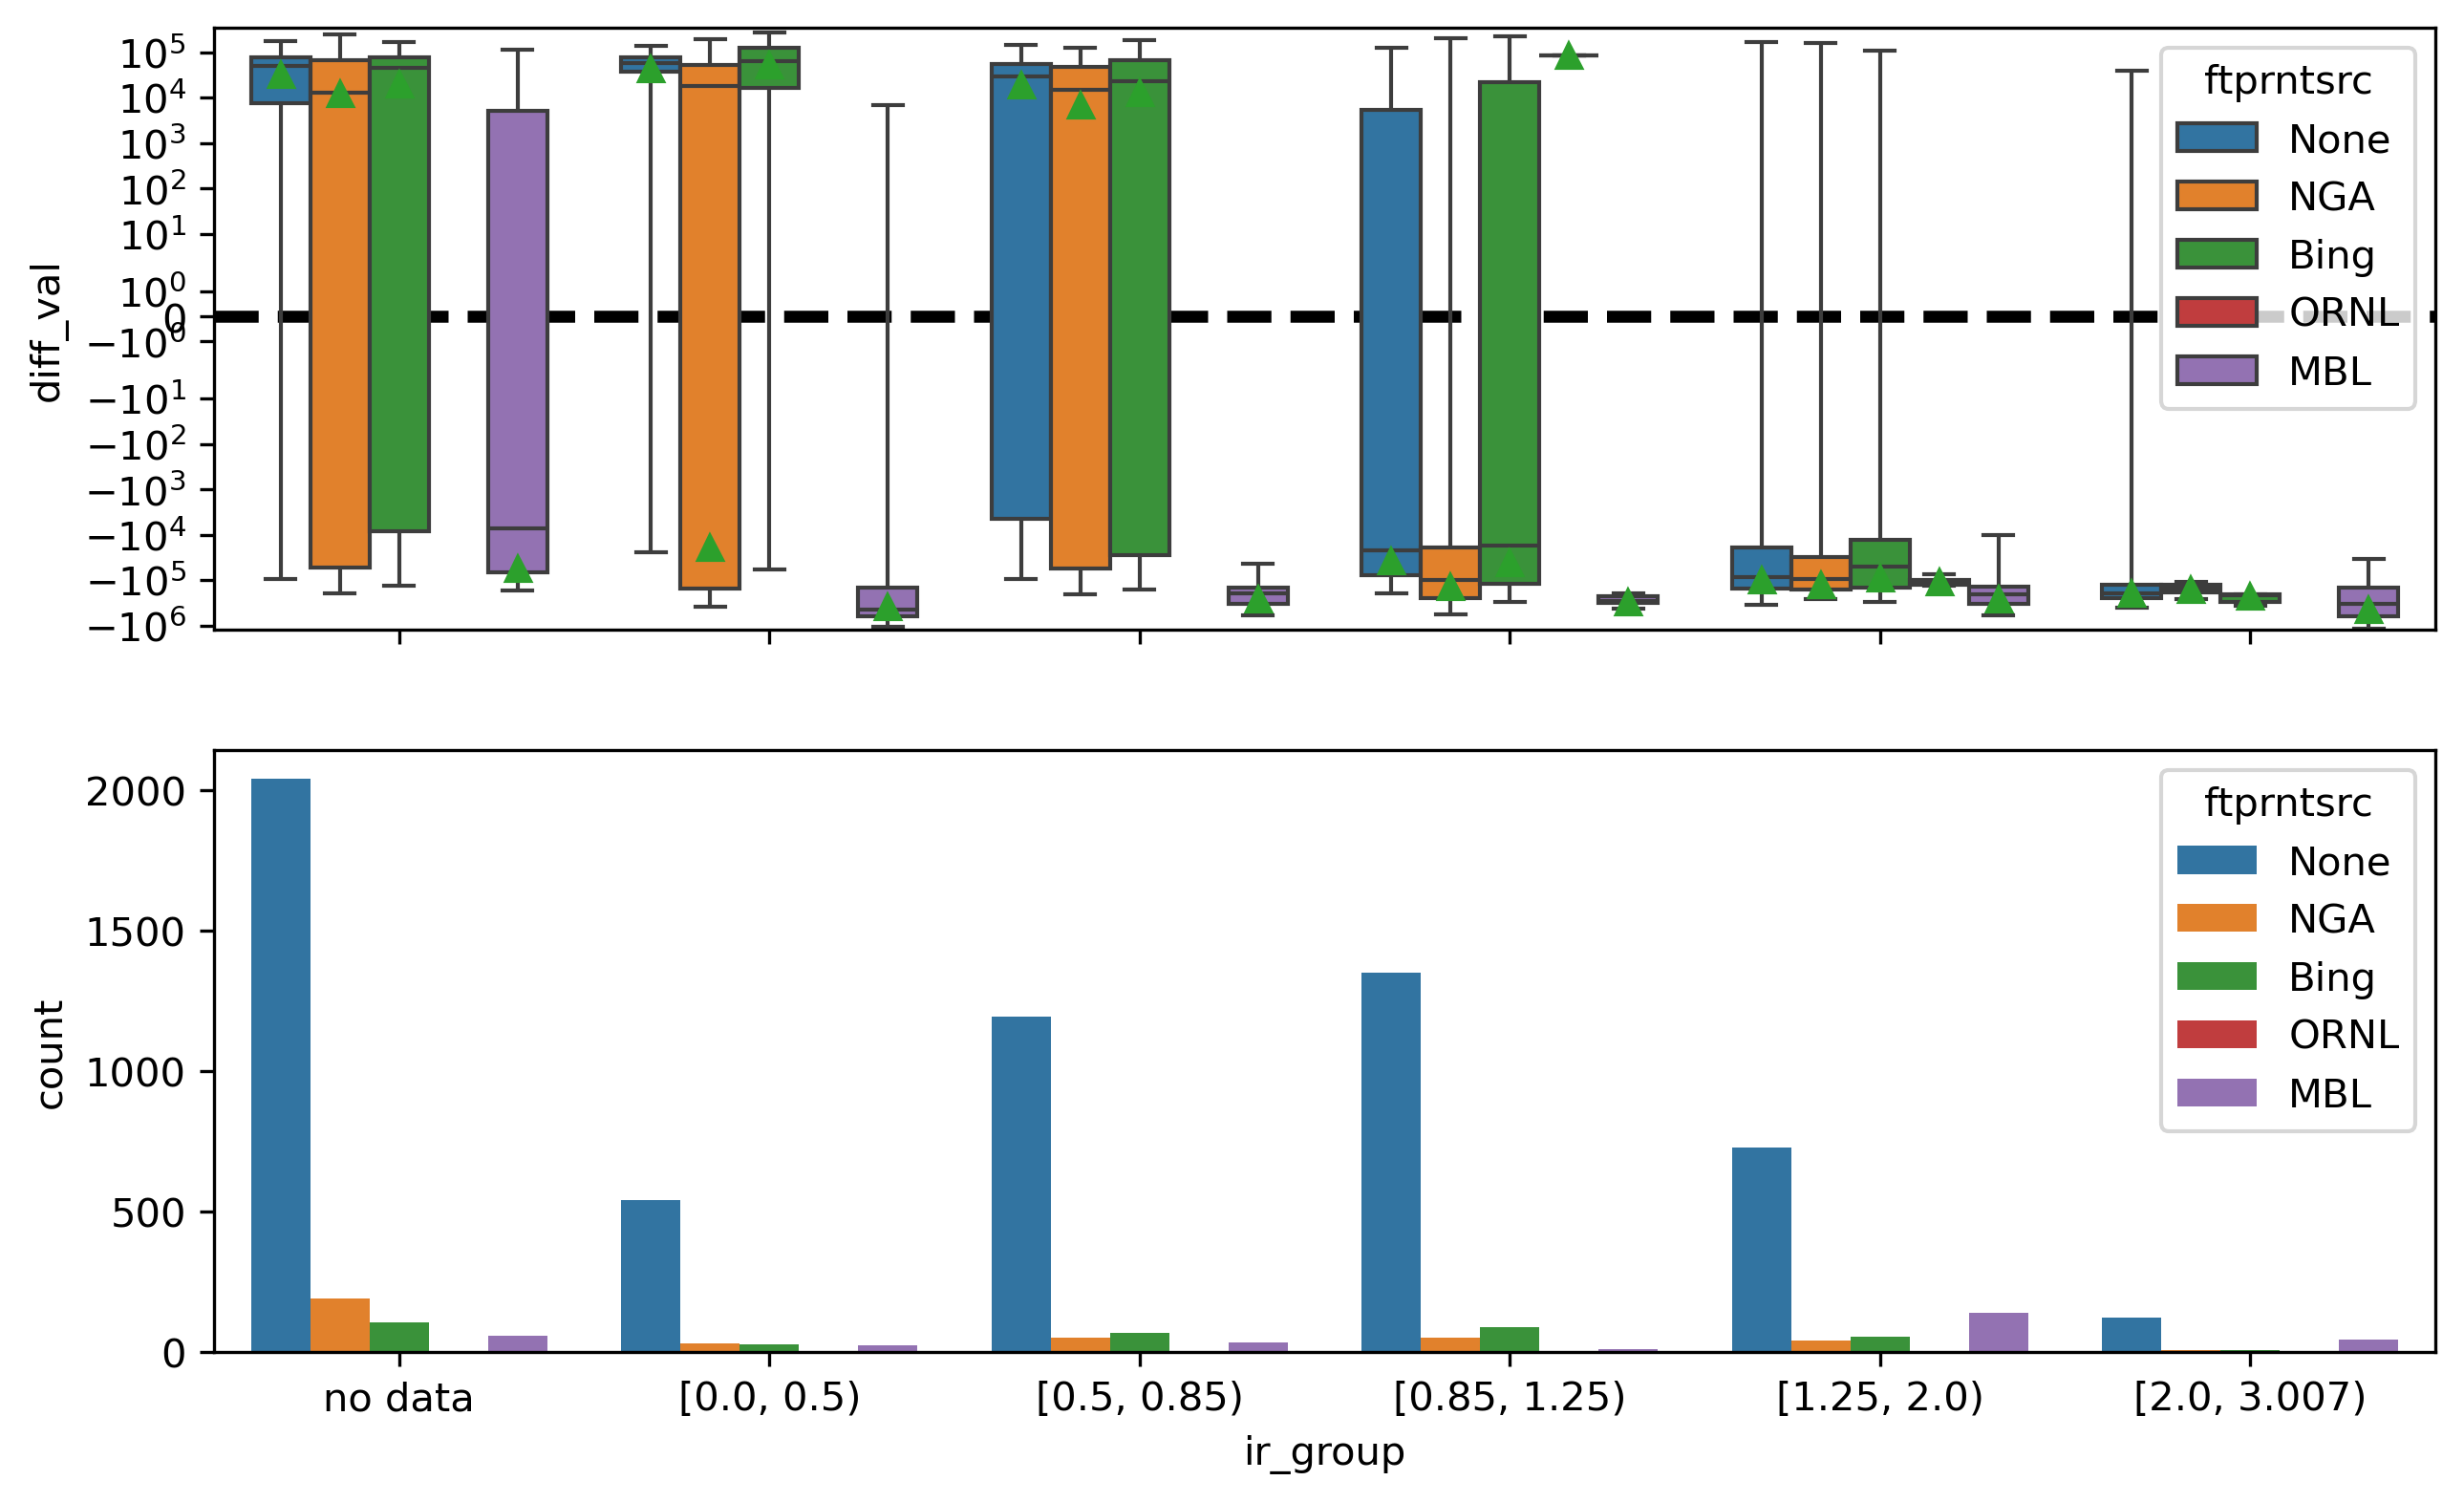

In [437]:
fig, ax = plt.subplots(figsize=(10, 6),
                       nrows=2,
                       sharex=True,
                       dpi=300)

sns.boxplot(data=all_comp,
            x='ir_group',
            hue='ftprntsrc',
            order=['no data', 
                   pd.Interval(0.0, 0.5, closed='left'),
                   pd.Interval(0.5, 0.85, closed='left'),
                   pd.Interval(0.85, 1.25, closed='left'),
                   pd.Interval(1.25, 2.0, closed='left'),
                   pd.Interval(2.0, 3.007, closed='left')],
            showfliers=False,
            y='diff_val',
            showmeans=True,
            ax=ax[0])

ax[0].set_yscale('symlog')
ax[0].axhline(0, color='black', ls='--', lw=3, zorder=0)

sns.countplot(data=all_comp,
              x='ir_group',
              hue='ftprntsrc',
              order=['no data', 
                   pd.Interval(0.0, 0.5, closed='left'),
                   pd.Interval(0.5, 0.85, closed='left'),
                   pd.Interval(0.85, 1.25, closed='left'),
                   pd.Interval(1.25, 2.0, closed='left'),
                   pd.Interval(2.0, 3.007, closed='left')],
              ax=ax[1])

# all_comp.groupby(['ir_group', 'ftprntsrc'])['diff_val'].describe()

<Axes: xlabel='ir_group', ylabel='count'>

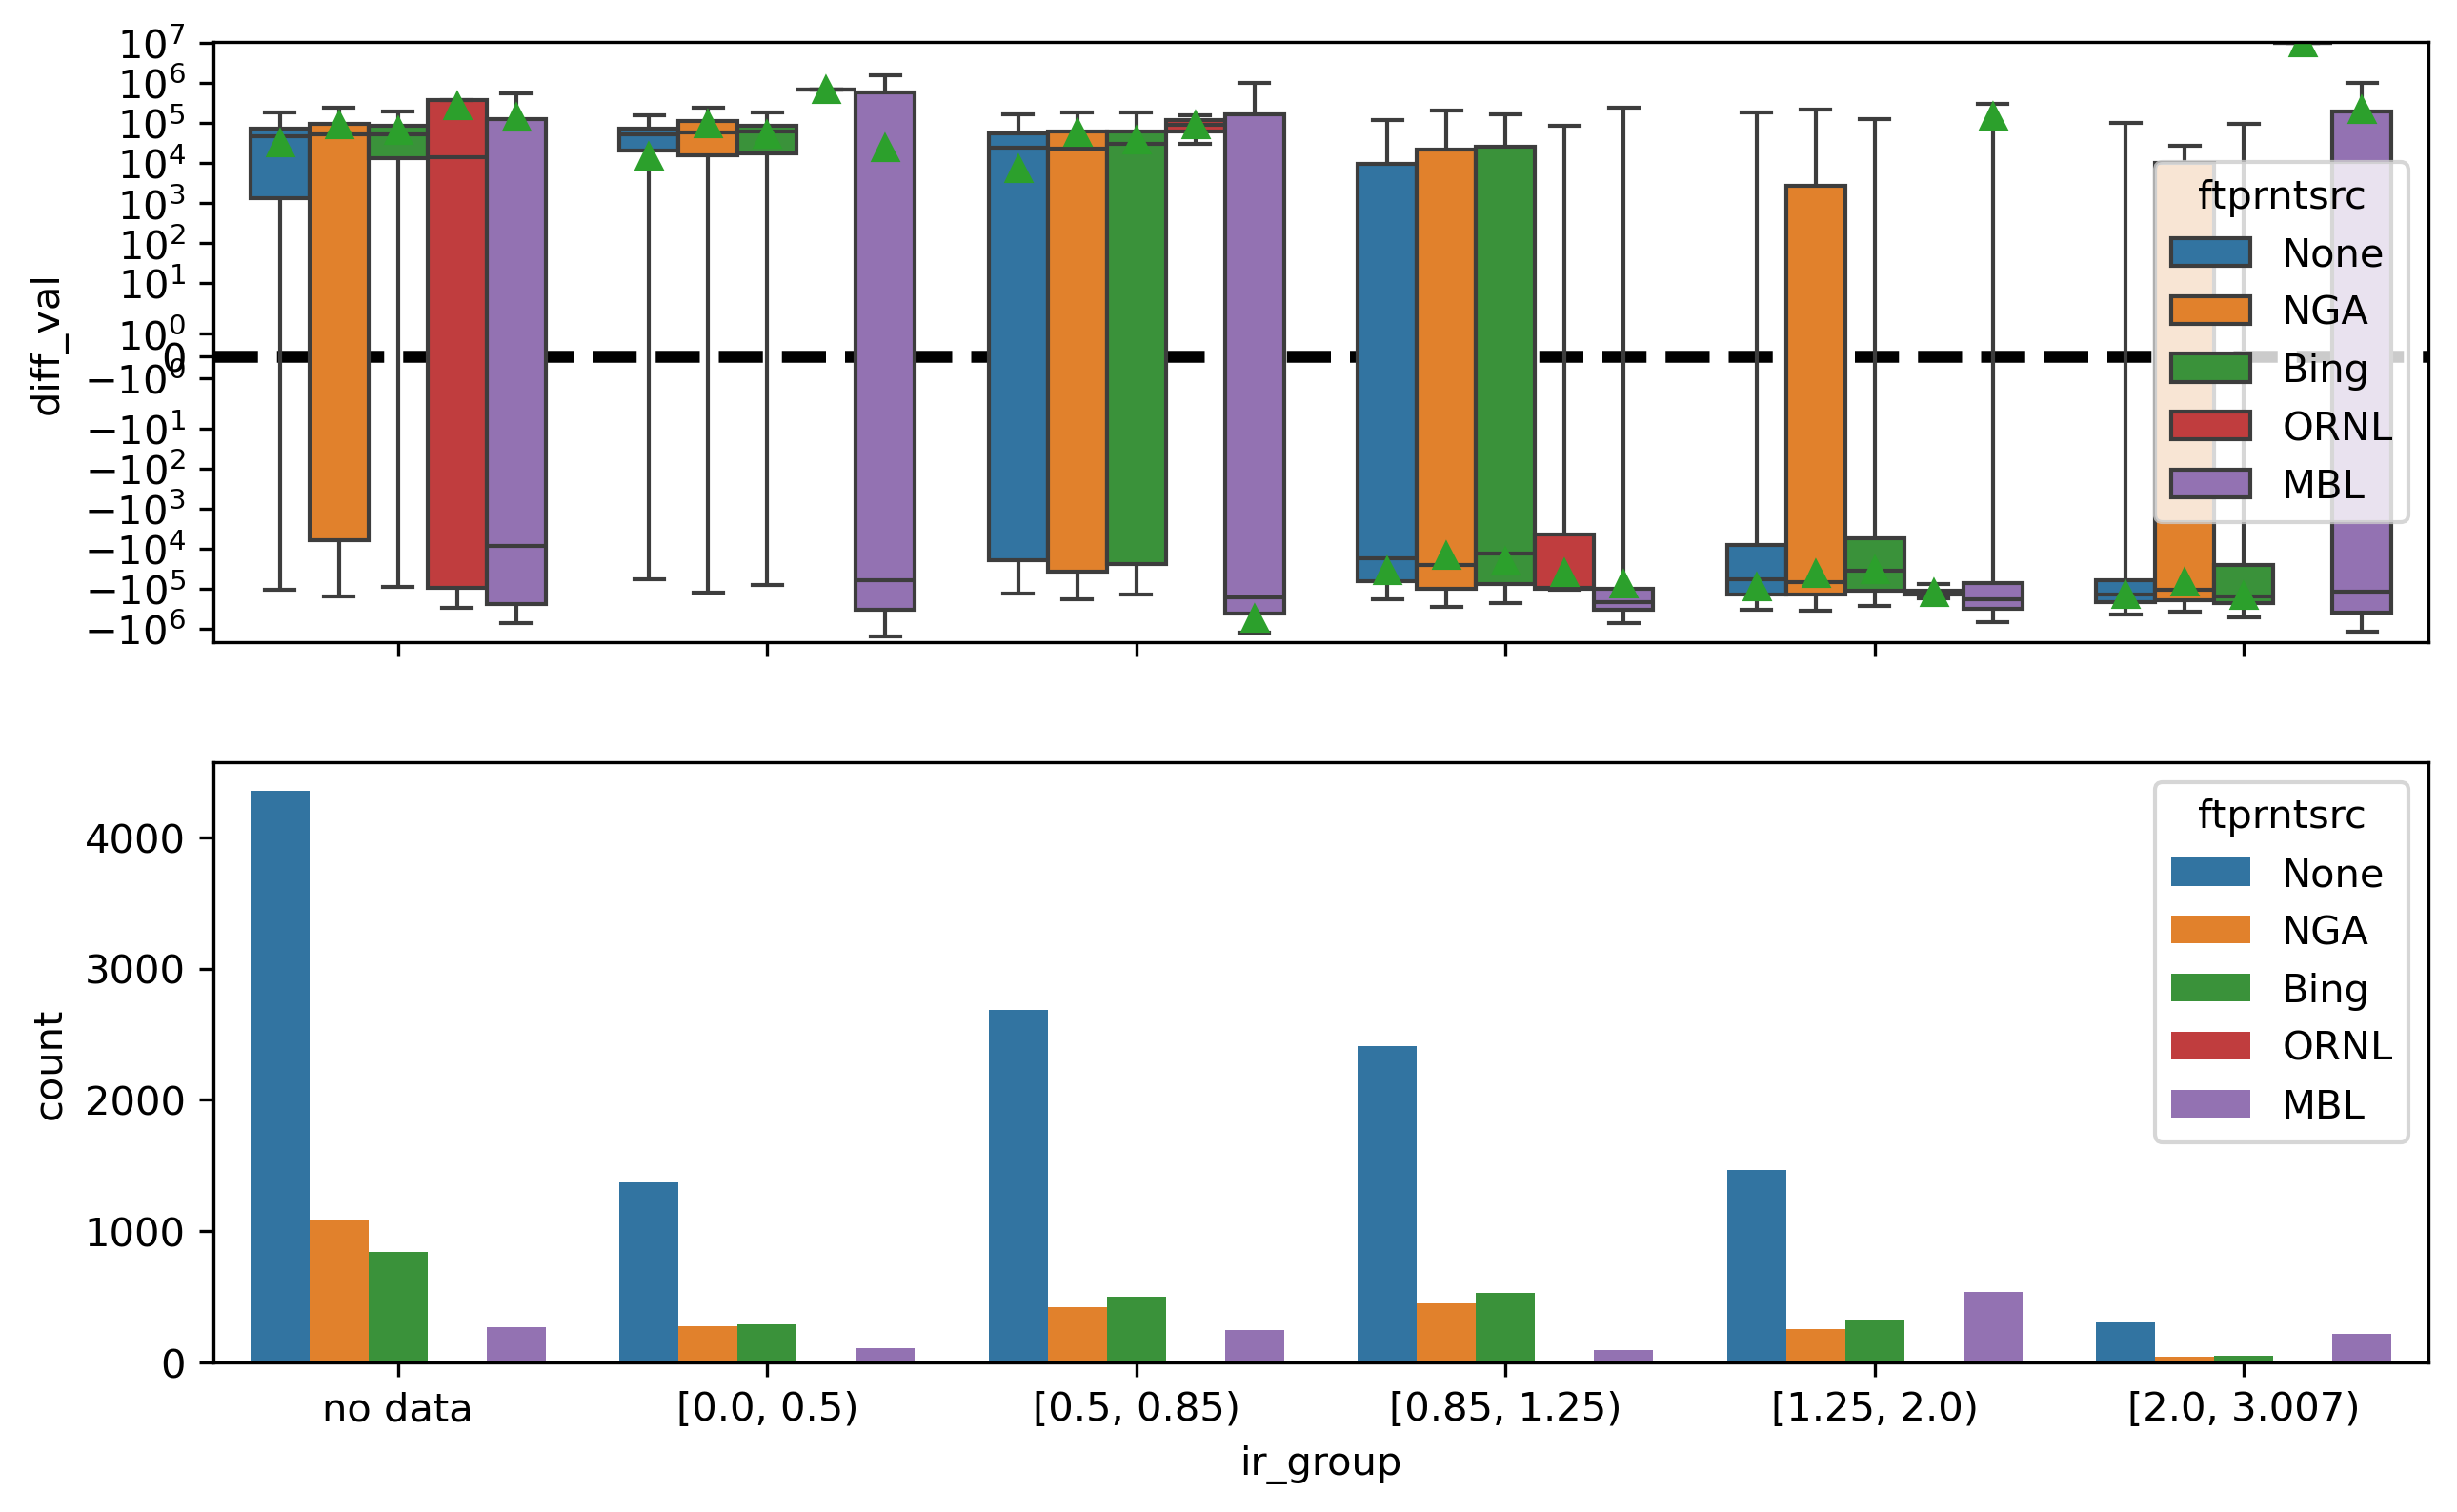

In [438]:
fig, ax = plt.subplots(figsize=(10, 6),
                       nrows=2,
                       sharex=True,
                       dpi=300)

sns.boxplot(data=nsi_val_check,
            x='ir_group',
            hue='ftprntsrc',
            order=['no data', 
                   pd.Interval(0.0, 0.5, closed='left'),
                   pd.Interval(0.5, 0.85, closed='left'),
                   pd.Interval(0.85, 1.25, closed='left'),
                   pd.Interval(1.25, 2.0, closed='left'),
                   pd.Interval(2.0, 3.007, closed='left')],
            showfliers=False,
            y='diff_val',
            showmeans=True,
            ax=ax[0])

ax[0].set_yscale('symlog')
ax[0].axhline(0, color='black', ls='--', lw=3, zorder=0)

sns.countplot(data=nsi_val_check,
              x='ir_group',
              hue='ftprntsrc',
              order=['no data', 
                   pd.Interval(0.0, 0.5, closed='left'),
                   pd.Interval(0.5, 0.85, closed='left'),
                   pd.Interval(0.85, 1.25, closed='left'),
                   pd.Interval(1.25, 2.0, closed='left'),
                   pd.Interval(2.0, 3.007, closed='left')],
              ax=ax[1])


In [309]:
phil_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_ref.pqt'))
nsi_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_ref.pqt'))

phil_inv_ens = phil_inv_ens.reset_index().merge(phil_refs[['bfid', 'bg_id']],
                                           on='bfid',
                                           how='left').set_index('bfid')

nsi_inv_ens = nsi_inv_ens.reset_index().merge(nsi_refs[['fd_id', 'bg_id']],
                                           on='fd_id',
                                           how='left').set_index('fd_id')

In [ ]:
# phil_vals = phil_inv_ens.groupby('bg_id')['val_struct'].median()
# nsi_vals = nsi_inv_ens.groupby('bg_id')['val_struct'].median()
# nsi_adj = (phil_vals/nsi_vals).fillna(0).rename('val_adj').reset_index()
# temp_vals = nsi_inv_ens[['bg_id', 'val_struct']].copy().reset_index()
# temp_vals = temp_vals.merge(nsi_adj, on='bg_id')
# temp_vals['val_struct'] = temp_vals['val_struct'] * temp_vals['val_adj'].clip(0, 2)
# val_upd = dict(zip(temp_vals['fd_id'], temp_vals['val_struct']))

phil_vals = phil_inv_ens.groupby('tract_id')['val_struct'].median()
temp_vals = nsi_inv_ens[['tract_id']].copy().reset_index()
temp_vals = temp_vals.merge(phil_vals, on='tract_id')
temp_vals['val_struct'] = temp_vals['val_struct'].fillna(0)
val_upd = dict(zip(temp_vals['fd_id'], temp_vals['val_struct']))

In [433]:
val_update_check_t = nsi_ddf_unc.copy()
val_update_check_t['val_update'] = val_update_check_t['fd_id'].map(val_upd)

In [434]:
val_update_check_t['dam_update'] = val_update_check_t['rel_loss'] * val_update_check_t['val_update']
val_update_check_t.groupby(['fd_id'])['dam_update'].mean().sum()/1e6

np.float64(391.763987682641)

In [401]:
val_update_check_t.groupby(['fd_id'])['naccs_loss_009'].mean().sum()/1e6

np.float64(441.3552861418581)

NOTE TO SELF
Need to incorporate some supplementary analysis on matches based on input data sources

In [ ]:
nsi_clip_out.loc[nsi_clip_out['ftprntsrc'].isnull(), 'ftprntsrc'] = 'None'
source_dict = dict(zip(nsi_clip_out['fd_id'],
                       nsi_clip_out['source'] + '_' + nsi_clip_out['ftprntsrc']))
match_df['src_nsi'] = match_df['fd_id'].map(source_dict)
bfid_src_dict = dict(zip(match_df['bfid'], match_df['src_nsi']))
test_gb['src_nsi'] = test_gb['bfid'].map(bfid_src_dict)

In [ ]:
pd.crosstab(test_gb['Matches'], test_gb['src_nsi'])

In [ ]:
depth_max = test_gb[(test_gb['Matches'] != 'NSI Not In Philly')]['depth_ft'].max()
anom = test_gb[(test_gb['Matches'] == 'NSI Not In Philly') & (test_gb['depth_plot'] > depth_max)]
dam_anom = anom['diff'].sum()/1e6
count_anom = len(anom)
prop_anom = 1e6*dam_anom/test_gb[(test_gb['Matches'] == 'NSI Not In Philly')]['diff'].sum()

print(f'Anom depth: {depth_max} ft.')
print(f'Total Anom: ${dam_anom}M')
print(f'Count Anom: {count_anom}')
print(f'Prop Anom: {prop_anom}')

In [ ]:
anom['src_nsi'] = anom['bfid'].map(bfid_src_dict)
pd.crosstab(anom['Matches'], anom['src_nsi'])